# Marine 48h Forecast — Hybrid: iTransformer + DeepAR by Parameter

`Marine_Forecast_RealEMS_iTransformer_Only.ipynb` showed a single iTransformer winning
18 of 24 parameters decisively (median skill in the 58-96% range) but **failing badly**
on the other 6 — all with deeply negative skill (−100% to −410%):

| Parameter | Pure iTransformer skill |
|---|---|
| `twentyFourHourAvgVisibility` | −100.0% |
| `precipitationDifference` | −101.9% |
| `tenMinuteAvgVisibility` | −154.9% |
| `oneMinuteAvgVisibility` | −190.5% |
| `oneHourAvgVisibility` | −291.6% |
| `precipitationIntensity` | −409.9% |

These 6 share two traits that punish a deterministic, point-forecast, multivariate
direct-horizon model: the 4 visibility parameters spend most of their time pinned at a
**sensor ceiling** (~18,000-20,000m) with rare, sharp drops; the 2 precipitation
parameters are **bursty and zero-inflated** (~30 rain events in 28 days). A model
trained to minimize MSE jointly across all 24 channels has no incentive to be
conservative on these — and the 11-model comparison already showed *which* model
**does** handle them best: **DeepAR**, every time, because training on Gaussian
negative log-likelihood instead of raw MSE produces a smoother, more risk-averse mean
estimate that loses *least* on exactly this kind of bursty/saturating data (it didn't
win by being accurate — its skill on these 6 is also negative, just far less so than
iTransformer's).

**This notebook builds the hybrid explicitly**: one iTransformer (loss computed only
over the 18 "good" parameters, so it doesn't waste capacity fighting the volatile 6),
one DeepAR (full multivariate, as it must be for its recursive rollout, but only its
forecast for the 6 "hard" parameters is actually served) — then merges them into a
single 24-parameter forecast and compares the hybrid's skill against the pure-iTransformer
baseline on exactly those 6 parameters.

Fully standalone: does not modify or depend on any other notebook or dashboard in this
project.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| torch threads:", torch.get_num_threads())


PyTorch: 2.12.1+cpu | torch threads: 8


## 1. Load data, collapse duplicates, encode circular parameters

Identical preprocessing to the other real-data notebooks (same cached
`ems_10min_resampled.csv`, same 6-duplicate collapse, same 3 circular encodings).

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)
DUPLICATES = [
    ("airTemperature", "windChillTemperature"),
    ("tideLevel", "tidePressure"),
    ("tideLevel", "waterPressure"),
    ("tideLevel", "waterLevel"),
    ("waterTemperature", "waterTemperature_WQ"),
    ("significantWaveHeight", "maxWaveHeight"),
]
df_cat = df_10min[["precipitationType"]].copy()
df_num = df_10min.drop(columns=["precipitationType"]).copy()

CIRCULAR = ["windDirection", "currentDirection", "compass"]
for c in CIRCULAR:
    rad = np.deg2rad(df_num[c])
    df_num[f"{c}_sin"] = np.sin(rad)
    df_num[f"{c}_cos"] = np.cos(rad)
df_num_full = df_num.drop(columns=CIRCULAR)

target_cols = [c for c in df_num_full.columns if c not in [d for _, d in DUPLICATES]]
n_targets = len(target_cols)
print(f"Modeled channels: {n_targets}")


Modeled channels: 27


## 2. Split responsibility: iTransformer (18) vs. DeepAR (6)

Exactly the 6 parameters that scored negative for the pure iTransformer notebook go to
DeepAR; the other 18 (incl. all 3 circular parameters and all 4 kept "duplicate twins")
stay with iTransformer.

In [3]:
HARD_PARAMS = [
    "twentyFourHourAvgVisibility", "precipitationDifference", "tenMinuteAvgVisibility",
    "oneMinuteAvgVisibility", "oneHourAvgVisibility", "precipitationIntensity",
]
GOOD_PARAMS = [c for c in target_cols if c not in HARD_PARAMS
               and not any(c == f"{ang}_{s}" for ang in ["windDirection", "currentDirection", "compass"] for s in ["sin", "cos"])]
# circular sin/cos pairs are reconstructed to degrees later, but the *_sin/_cos channels
# themselves are still iTransformer-modeled directly (they're not in HARD_PARAMS)
GOOD_PARAMS = [c for c in target_cols if c not in HARD_PARAMS]

print(f"iTransformer handles {len(GOOD_PARAMS)} channels:")
print(GOOD_PARAMS)
print(f"\nDeepAR handles (and is the ONLY model SERVED for) {len(HARD_PARAMS)} parameters:")
print(HARD_PARAMS)
assert len(GOOD_PARAMS) + len(HARD_PARAMS) == n_targets


iTransformer handles 21 channels:
['airTemperature', 'airPressure', 'relativeHumidity', 'dewPointTemperature', 'windSpeed', 'globalRadiation', 'currentSpeed', 'tideLevel', 'waterTemperature', 'conductivity', 'salinity', 'significantWaveHeight', 'significantWavePeriod', 'peakWaveEnergyPeriod', 'zeroCrossingPeriod', 'windDirection_sin', 'windDirection_cos', 'currentDirection_sin', 'currentDirection_cos', 'compass_sin', 'compass_cos']

DeepAR handles (and is the ONLY model SERVED for) 6 parameters:
['twentyFourHourAvgVisibility', 'precipitationDifference', 'tenMinuteAvgVisibility', 'oneMinuteAvgVisibility', 'oneHourAvgVisibility', 'precipitationIntensity']


## 3. Train/test split, duplicate reconstruction fit, scaling

In [4]:
LOOKBACK, HORIZON = 288, 288   # 2 days lookback, 48h horizon @ 10-min steps

idx = df_num_full.index
df_num_full["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
df_num_full["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
df_num_full["dom_sin"] = np.sin(2 * np.pi * idx.day / 30)
df_num_full["dom_cos"] = np.cos(2 * np.pi * idx.day / 30)
calendar_cols = ["hour_sin", "hour_cos", "dom_sin", "dom_cos"]

feature_cols = target_cols + calendar_cols
model_data = df_num_full[feature_cols].copy()
n_features = len(feature_cols)
target_idx = [feature_cols.index(c) for c in target_cols]
good_idx = [feature_cols.index(c) for c in GOOD_PARAMS]      # indices within feature_cols
hard_idx = [feature_cols.index(c) for c in HARD_PARAMS]
calendar_idx = [feature_cols.index(c) for c in calendar_cols]

train_df = model_data.iloc[:-HORIZON].copy()
test_df = model_data.iloc[-HORIZON:].copy()
mean, std = train_df.mean(), train_df.std().replace(0, 1)
train_scaled = (train_df - mean) / std
full_scaled = (model_data - mean) / std
future_calendar_scaled = full_scaled[calendar_cols].iloc[-HORIZON:].values.astype(np.float32)

print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/144:.1f} days)")
print(f"Test : {test_df.shape[0]} rows ({test_df.shape[0]/144:.1f} days)")


Train: 4032 rows (28.0 days)
Test : 288 rows (2.0 days)


In [5]:
recon_coef = {}
for keep, drop in DUPLICATES:
    x, y = train_df[keep].values, df_num_full[drop].iloc[:-HORIZON].values
    slope, intercept = np.polyfit(x, y, 1)
    pred_train = slope * x + intercept
    r2 = 1 - np.sum((y - pred_train) ** 2) / np.sum((y - y.mean()) ** 2)
    recon_coef[drop] = (keep, float(slope), float(intercept), float(r2))
    engine = "iTransformer" if keep in GOOD_PARAMS else "DeepAR"
    print(f"  reconstruct {drop:25s} = {slope:.4f} * {keep} + {intercept:.4f}   "
          f"(R^2={r2:.5f}, from {engine}'s forecast of {keep})")


  reconstruct windChillTemperature      = 1.0000 * airTemperature + 0.0000   (R^2=1.00000, from iTransformer's forecast of airTemperature)
  reconstruct tidePressure              = 399.7841 * tideLevel + 9800.2149   (R^2=0.99976, from iTransformer's forecast of tideLevel)
  reconstruct waterPressure             = 100.6985 * tideLevel + 5040.9916   (R^2=0.99992, from iTransformer's forecast of tideLevel)
  reconstruct waterLevel                = 0.2248 * tideLevel + 0.2877   (R^2=0.99528, from iTransformer's forecast of tideLevel)
  reconstruct waterTemperature_WQ       = 1.0000 * waterTemperature + 0.0001   (R^2=0.99985, from iTransformer's forecast of waterTemperature)
  reconstruct maxWaveHeight             = 1.6496 * significantWaveHeight + 0.1208   (R^2=0.99907, from iTransformer's forecast of significantWaveHeight)


## 4. Model A — iTransformer, loss computed only on the 18 "good" parameters

Same architecture as the single-model notebook, but `target_idx` is now restricted to
`GOOD_PARAMS` — the network still sees all 31 channels (targets + calendar) as input
tokens (full context for its cross-variate attention), but training only optimizes
predictions for the 18 channels it's actually being asked to serve.

In [6]:
def make_direct_windows(scaled_df, lookback, horizon, out_idx):
    arr = scaled_df.values.astype(np.float32)
    X, Y = [], []
    for origin in range(lookback, len(arr) - horizon):
        X.append(arr[origin - lookback:origin])
        Y.append(arr[origin:origin + horizon][:, out_idx])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_direct, Y_good = make_direct_windows(train_scaled, LOOKBACK, HORIZON, good_idx)
X_t, Y_good_t = torch.from_numpy(X_direct), torch.from_numpy(Y_good)
n_val = max(1, int(0.1 * len(X_t)))
X_tr, Y_tr_good = X_t[:-n_val], Y_good_t[:-n_val]
X_val, Y_val_good = X_t[-n_val:], Y_good_t[-n_val:]
last_window = torch.from_numpy(train_scaled.values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)
print(f"iTransformer training windows: {len(X_tr)} train / {len(X_val)} val, "
      f"output dim = {len(good_idx)} (vs {n_targets} if it modeled everything)")


iTransformer training windows: 3111 train / 345 val, output dim = 21 (vs 27 if it modeled everything)


In [7]:
class ITransformer(nn.Module):
    def __init__(self, lookback, n_features, horizon, out_idx, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.out_idx = out_idx
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok)
        return out.transpose(1, 2)[:, :, self.out_idx]

    def embed_tokens(self, x):
        return self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)


def train_model(model, X_tr, Y_tr, X_val, Y_val, epochs=150, batch_size=64, lr=1e-3,
                 patience=20, name=""):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    loss_fn = nn.MSELoss()
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, yb = X_tr[b].to(device), Y_tr[b].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val.to(device)), Y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [{name}] epoch {ep+1:3d}/{epochs}  val_loss={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-5:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    print(f"{name:14s} best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

itransformer = ITransformer(LOOKBACK, n_features, HORIZON, good_idx, d_model=64, n_heads=4, n_layers=2)
itransformer = train_model(itransformer, X_tr, Y_tr_good, X_val, Y_val_good, epochs=150, patience=20,
                            name="iTransformer")

with torch.no_grad():
    good_pred_scaled = itransformer(last_window.to(device))[0].cpu().numpy()
good_preds_real = good_pred_scaled * std[GOOD_PARAMS].values + mean[GOOD_PARAMS].values
good_pred_df = pd.DataFrame(good_preds_real, columns=GOOD_PARAMS, index=test_df.index)
print("iTransformer 48h forecast complete (18 parameters).")


  [iTransformer] epoch   1/150  val_loss=0.4280  epoch_time=0.9s  elapsed=1s


  [iTransformer] epoch   2/150  val_loss=0.3269  epoch_time=0.8s  elapsed=2s


  [iTransformer] epoch   3/150  val_loss=0.2639  epoch_time=0.8s  elapsed=2s


  [iTransformer] epoch   4/150  val_loss=0.2357  epoch_time=0.7s  elapsed=3s


  [iTransformer] epoch   5/150  val_loss=0.2015  epoch_time=0.8s  elapsed=4s


...

  [iTransformer] epoch 147/150  val_loss=0.0368  epoch_time=1.1s  elapsed=185s


  [iTransformer] epoch 148/150  val_loss=0.0366  epoch_time=1.1s  elapsed=186s


  [iTransformer] epoch 149/150  val_loss=0.0367  epoch_time=1.2s  elapsed=187s


  [iTransformer] epoch 150/150  val_loss=0.0365  epoch_time=1.1s  elapsed=188s


iTransformer   best_val_loss=0.0365  epochs_run=150  time=188.1s
iTransformer 48h forecast complete (18 parameters).


## 5. Model B — DeepAR, full multivariate (its recursive rollout requires it),
serving only the 6 "hard" parameters

DeepAR's architecture must reconstruct the **full** feature vector at every recursive
step (it feeds its own prediction back in as the next input), so it cannot be restricted
to predicting only 6 channels the way iTransformer's direct-horizon output can be. It's
trained on all 27 channels as before; only its forecast for `HARD_PARAMS` is actually
served in the final hybrid output.

In [8]:
def make_seq2one(arr, lookback):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i - lookback:i]); y.append(arr[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

train_arr = train_scaled.values.astype(np.float32)
X_seq, y_seq = make_seq2one(train_arr, LOOKBACK)
X_seq_t, y_seq_t = torch.from_numpy(X_seq), torch.from_numpy(y_seq)
n_val_s = max(1, int(0.1 * len(X_seq_t)))
X_seq_tr, y_seq_tr = X_seq_t[:-n_val_s], y_seq_t[:-n_val_s]
X_seq_val, y_seq_val = X_seq_t[-n_val_s:], y_seq_t[-n_val_s:]


class DeepAR(nn.Module):
    def __init__(self, n_features, hidden1=96, hidden2=48, dropout=0.2):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.mu_head = nn.Linear(hidden2, n_features)
        self.logsigma_head = nn.Linear(hidden2, n_features)

    def forward(self, x):
        x, _ = self.lstm1(x); x = self.drop1(x)
        _, (h, _) = self.lstm2(x)
        h = self.drop2(h[-1])
        return self.mu_head(h), self.logsigma_head(h).clamp(-6, 3)


def gaussian_nll(mu, log_sigma, target):
    sigma = torch.exp(log_sigma)
    return (0.5 * ((target - mu) / sigma) ** 2 + log_sigma).mean()


def train_deepar(model, X_tr, y_tr, X_val, y_val, epochs=50, batch_size=64, lr=1e-3, patience=8):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, yb = X_tr[b].to(device), y_tr[b].to(device)
            opt.zero_grad()
            mu, log_sigma = model(xb)
            loss = gaussian_nll(mu, log_sigma, yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            mu, log_sigma = model(X_val.to(device))
            val_loss = gaussian_nll(mu, log_sigma, y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [DeepAR] epoch {ep+1:3d}/{epochs}  val_nll={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-4:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    print(f"{'DeepAR':14s} best_val_nll={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

deepar = DeepAR(n_features)
deepar = train_deepar(deepar, X_seq_tr, y_seq_tr, X_seq_val, y_seq_val)


  [DeepAR] epoch   1/50  val_nll=0.0327  epoch_time=22.4s  elapsed=22s


  [DeepAR] epoch   2/50  val_nll=-0.2651  epoch_time=3.3s  elapsed=26s


  [DeepAR] epoch   3/50  val_nll=-0.3896  epoch_time=3.9s  elapsed=30s


  [DeepAR] epoch   4/50  val_nll=-0.4828  epoch_time=3.8s  elapsed=33s


  [DeepAR] epoch   5/50  val_nll=-0.5419  epoch_time=3.3s  elapsed=37s


...

  [DeepAR] epoch  45/50  val_nll=-0.9719  epoch_time=3.9s  elapsed=176s


  [DeepAR] epoch  46/50  val_nll=-0.9737  epoch_time=3.2s  elapsed=179s


  [DeepAR] epoch  47/50  val_nll=-0.9934  epoch_time=3.1s  elapsed=183s


  [DeepAR] epoch  48/50  val_nll=-1.0193  epoch_time=3.2s  elapsed=186s


DeepAR         best_val_nll=-1.1028  epochs_run= 48  time=185.7s


In [9]:
N_MC_SAMPLES = 50
deepar.eval()
all_paths = np.zeros((N_MC_SAMPLES, HORIZON, n_features), dtype=np.float32)
with torch.no_grad():
    for s in range(N_MC_SAMPLES):
        window = train_arr[-LOOKBACK:].copy()
        for h in range(HORIZON):
            x_in = torch.from_numpy(window).unsqueeze(0).to(device)
            mu, log_sigma = deepar(x_in)
            mu_np, sigma_np = mu[0].cpu().numpy(), torch.exp(log_sigma)[0].cpu().numpy()
            sample = mu_np + sigma_np * np.random.randn(n_features).astype(np.float32)
            sample[calendar_idx] = future_calendar_scaled[h]
            all_paths[s, h] = sample
            window = np.vstack([window[1:], sample])

deepar_mean_scaled = all_paths.mean(axis=0)
deepar_std_scaled = all_paths.std(axis=0)
deepar_mean_real = deepar_mean_scaled[:, target_idx] * std[target_cols].values + mean[target_cols].values
deepar_std_real = deepar_std_scaled[:, target_idx] * std[target_cols].values
deepar_pred_df_full = pd.DataFrame(deepar_mean_real, columns=target_cols, index=test_df.index)
deepar_std_df_full = pd.DataFrame(deepar_std_real, columns=target_cols, index=test_df.index)

hard_pred_df = deepar_pred_df_full[HARD_PARAMS].copy()
hard_std_df = deepar_std_df_full[HARD_PARAMS].copy()
print(f"DeepAR: {N_MC_SAMPLES} Monte-Carlo sample paths complete. "
      f"Serving its forecast for: {HARD_PARAMS}")


DeepAR: 50 Monte-Carlo sample paths complete. Serving its forecast for: ['twentyFourHourAvgVisibility', 'precipitationDifference', 'tenMinuteAvgVisibility', 'oneMinuteAvgVisibility', 'oneHourAvgVisibility', 'precipitationIntensity']


## 6. Merge into the hybrid forecast, reconstruct circular params & duplicates

In [10]:
hybrid_pred_df = pd.concat([good_pred_df, hard_pred_df], axis=1)[target_cols]

def reconstruct(pred_df_in):
    out = pred_df_in.copy()
    for ang in ["windDirection", "currentDirection", "compass"]:
        out[ang] = (np.rad2deg(np.arctan2(out[f"{ang}_sin"], out[f"{ang}_cos"])) % 360)
    return out

hybrid_final = reconstruct(hybrid_pred_df)
truth = df_num_full.iloc[-HORIZON:].copy()
for ang in ["windDirection", "currentDirection", "compass"]:
    truth[ang] = (np.rad2deg(np.arctan2(truth[f"{ang}_sin"], truth[f"{ang}_cos"])) % 360)

report_params = [c for c in target_cols if not c.endswith(("_sin", "_cos"))] + \
                ["windDirection", "currentDirection", "compass"]
CIRCULAR_PARAMS = {"windDirection", "currentDirection", "compass"}
ENGINE = {p: ("DeepAR" if p in HARD_PARAMS else "iTransformer") for p in report_params}

dup_series = {}
for keep, drop in DUPLICATES:
    _, slope, intercept, _ = recon_coef[drop]
    dup_series[drop] = slope * hybrid_final[keep].values + intercept
    ENGINE[drop] = ENGINE[keep]   # inherits its kept twin's engine (always iTransformer here)

print("Hybrid forecast assembled: 18 from iTransformer + 6 from DeepAR + 6 duplicates reconstructed.")


Hybrid forecast assembled: 18 from iTransformer + 6 from DeepAR + 6 duplicates reconstructed.


## 7. Score the hybrid vs. persistence, and vs. the pure-iTransformer baseline

The pure-iTransformer skill values below are copied from
`Marine_Forecast_RealEMS_iTransformer_Only.ipynb`'s actual measured results (the table
in this notebook's introduction) — this directly answers "did swapping in DeepAR for
the hard 6 actually help?".

In [11]:
PURE_ITRANSFORMER_SKILL = {
    "currentDirection": 95.6, "windDirection": 95.5, "airTemperature": 95.4,
    "relativeHumidity": 93.6, "dewPointTemperature": 92.7, "tideLevel": 92.1,
    "waterTemperature": 92.0, "significantWaveHeight": 88.4, "windSpeed": 88.2,
    "airPressure": 87.2, "globalRadiation": 86.9, "currentSpeed": 83.9,
    "salinity": 78.7, "significantWavePeriod": 74.1, "zeroCrossingPeriod": 72.2,
    "compass": 67.6, "peakWaveEnergyPeriod": 58.0, "conductivity": 57.8,
    "twentyFourHourAvgVisibility": -100.0, "precipitationDifference": -101.9,
    "tenMinuteAvgVisibility": -154.9, "oneMinuteAvgVisibility": -190.5,
    "oneHourAvgVisibility": -291.6, "precipitationIntensity": -409.9,
}

def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

last_obs = df_num_full.iloc[-HORIZON - 1]
for ang in ["windDirection", "currentDirection", "compass"]:
    last_obs[ang] = (np.rad2deg(np.arctan2(last_obs[f"{ang}_sin"], last_obs[f"{ang}_cos"])) % 360)

metrics = []
for p in report_params:
    yt = truth[p].values
    yp_persist = np.repeat(last_obs[p], HORIZON)
    is_circular = p in CIRCULAR_PARAMS
    mae_p = circ_mae(yt, yp_persist) if is_circular else mean_absolute_error(yt, yp_persist)
    yhat = hybrid_final[p].values
    if is_circular:
        mae, rmse = circ_mae(yt, yhat), np.nan
    else:
        mae = mean_absolute_error(yt, yhat)
        rmse = np.sqrt(mean_squared_error(yt, yhat))
    skill = (1 - mae / mae_p) * 100 if mae_p > 0 else np.nan
    pure_skill = PURE_ITRANSFORMER_SKILL.get(p, np.nan)
    metrics.append({
        "parameter": p, "engine": ENGINE[p], "Persistence_MAE": round(mae_p, 4),
        "hybrid_MAE": round(mae, 4), "hybrid_RMSE": round(rmse, 4) if rmse == rmse else np.nan,
        "hybrid_skill_%": round(skill, 1), "pure_iTransformer_skill_%": pure_skill,
        "improvement_pp": round(skill - pure_skill, 1) if pure_skill == pure_skill else np.nan,
    })

metrics_df = pd.DataFrame(metrics).sort_values("hybrid_skill_%", ascending=False).reset_index(drop=True)
metrics_df.insert(0, "rank", metrics_df.index + 1)
metrics_df.to_csv("metrics_hybrid.csv", index=False)
metrics_df


,rank,parameter,engine,Persistence_MAE,hybrid_MAE,hybrid_RMSE,hybrid_skill_%,pure_iTransformer_skill_%,improvement_pp
0,1,airTemperature,iTransformer,5.8458,0.1163,0.1431,98.0,95.4,2.6
1,2,airPressure,iTransformer,5.1252,0.1219,0.1538,97.6,87.2,10.4
2,3,windDirection,iTransformer,73.1616,2.2917,NaN,96.9,95.5,1.4
3,4,waterTemperature,iTransformer,1.5273,0.0551,0.0692,96.4,92.0,4.4
4,5,relativeHumidity,iTransformer,18.7896,0.6970,0.8706,96.3,93.6,2.7
5,6,currentDirection,iTransformer,91.7282,3.6898,NaN,96.0,95.6,0.4
6,7,tideLevel,iTransformer,0.9216,0.0552,0.0679,94.0,92.1,1.9
7,8,dewPointTemperature,iTransformer,2.1046,0.1349,0.1679,93.6,92.7,0.9
8,9,globalRadiation,iTransformer,241.0507,16.8606,22.5266,93.0,86.9,6.1
9,10,significantWaveHeight,iTransformer,0.5027,0.0468,0.0599,90.7,88.4,2.3


## 8. Did the swap actually help on the 6 hard parameters?

In [12]:
hard_comparison = metrics_df[metrics_df["parameter"].isin(HARD_PARAMS)][
    ["parameter", "hybrid_skill_%", "pure_iTransformer_skill_%", "improvement_pp"]
].sort_values("improvement_pp", ascending=False)
print(hard_comparison.to_string(index=False))
print(f"\nMean improvement on the 6 hard parameters: {hard_comparison['improvement_pp'].mean():+.1f} percentage points")


                  parameter  hybrid_skill_%  pure_iTransformer_skill_%  improvement_pp
     precipitationIntensity            -0.2                     -409.9           409.7
       oneHourAvgVisibility            -1.4                     -291.6           290.2
     oneMinuteAvgVisibility            -2.5                     -190.5           188.0
     tenMinuteAvgVisibility            14.0                     -154.9           168.9
twentyFourHourAvgVisibility             3.5                     -100.0           103.5
    precipitationDifference            -0.1                     -101.9           101.8

Mean improvement on the 6 hard parameters: +210.3 percentage points


## 9. Plot a sample of parameters, colored by which engine served them

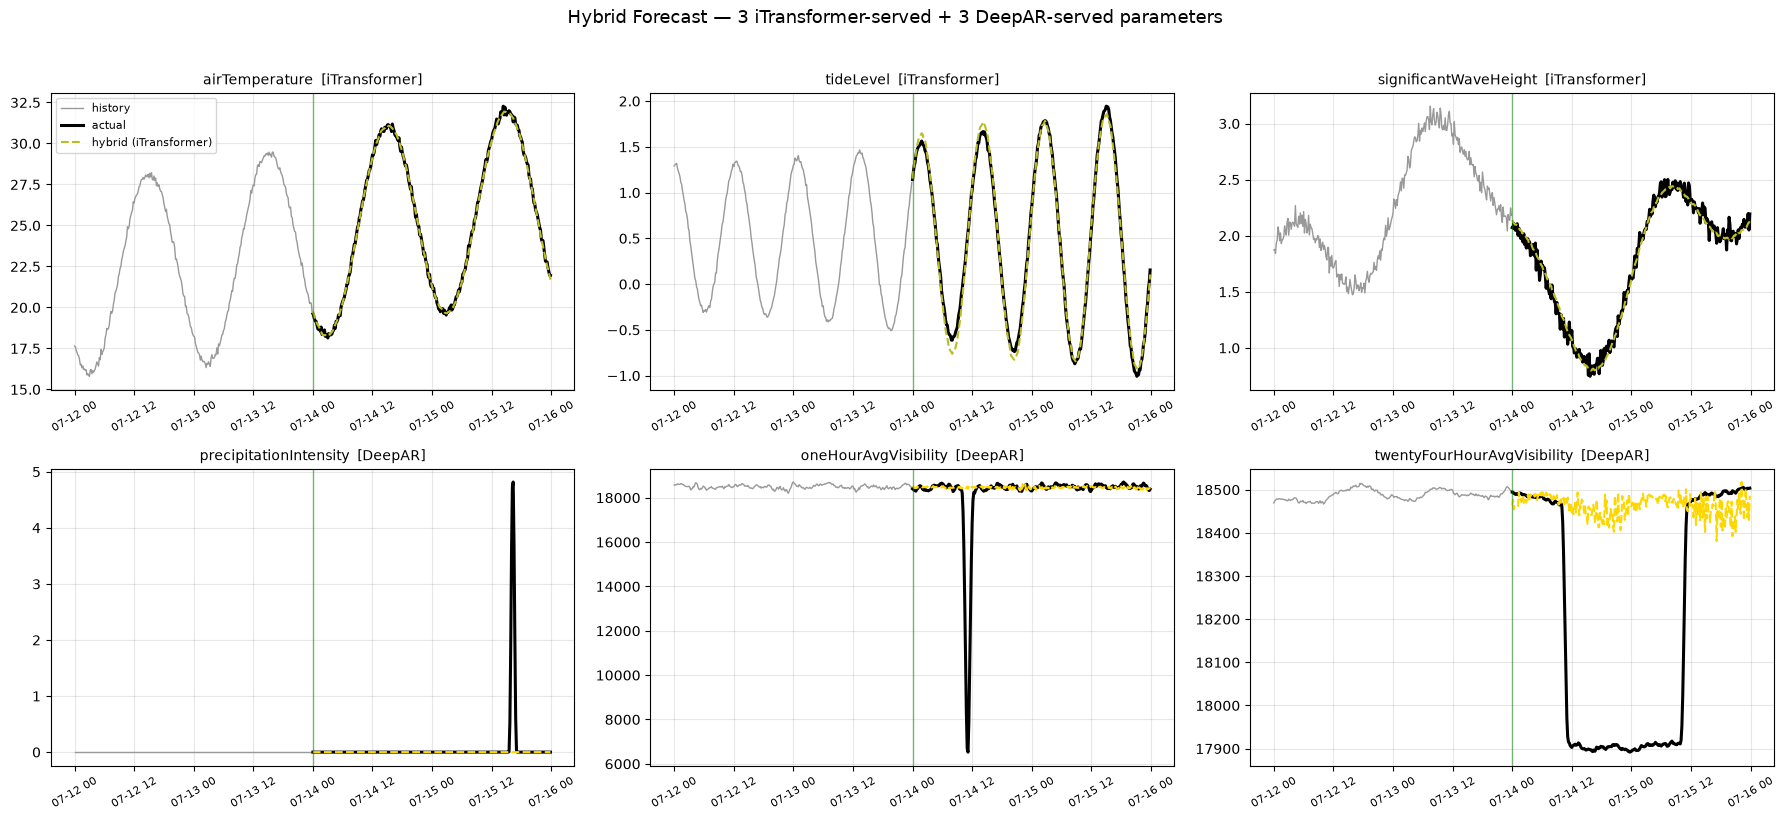

In [13]:
hist_tail = df_10min.iloc[-HORIZON - LOOKBACK:-HORIZON]
key_plots = ["airTemperature", "tideLevel", "significantWaveHeight",
             "precipitationIntensity", "oneHourAvgVisibility", "twentyFourHourAvgVisibility"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, p in zip(axes.ravel(), key_plots):
    ax.plot(hist_tail.index, hist_tail[p], color="0.6", lw=1, label="history")
    ax.plot(truth.index, truth[p], color="black", lw=2.2, label="actual")
    color = "#bcbd22" if ENGINE[p] == "iTransformer" else "#ffd700"
    ax.plot(truth.index, hybrid_final[p], color=color, lw=1.5, ls="--", label=f"hybrid ({ENGINE[p]})")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(f"{p}  [{ENGINE[p]}]", fontsize=10)
    ax.grid(alpha=0.3); ax.tick_params(axis="x", rotation=30, labelsize=8)
axes.ravel()[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Hybrid Forecast — 3 iTransformer-served + 3 DeepAR-served parameters", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("forecast_plots_hybrid.png", dpi=110, bbox_inches="tight")
plt.show()


## 10. Attention map (iTransformer's 18 parameters only)

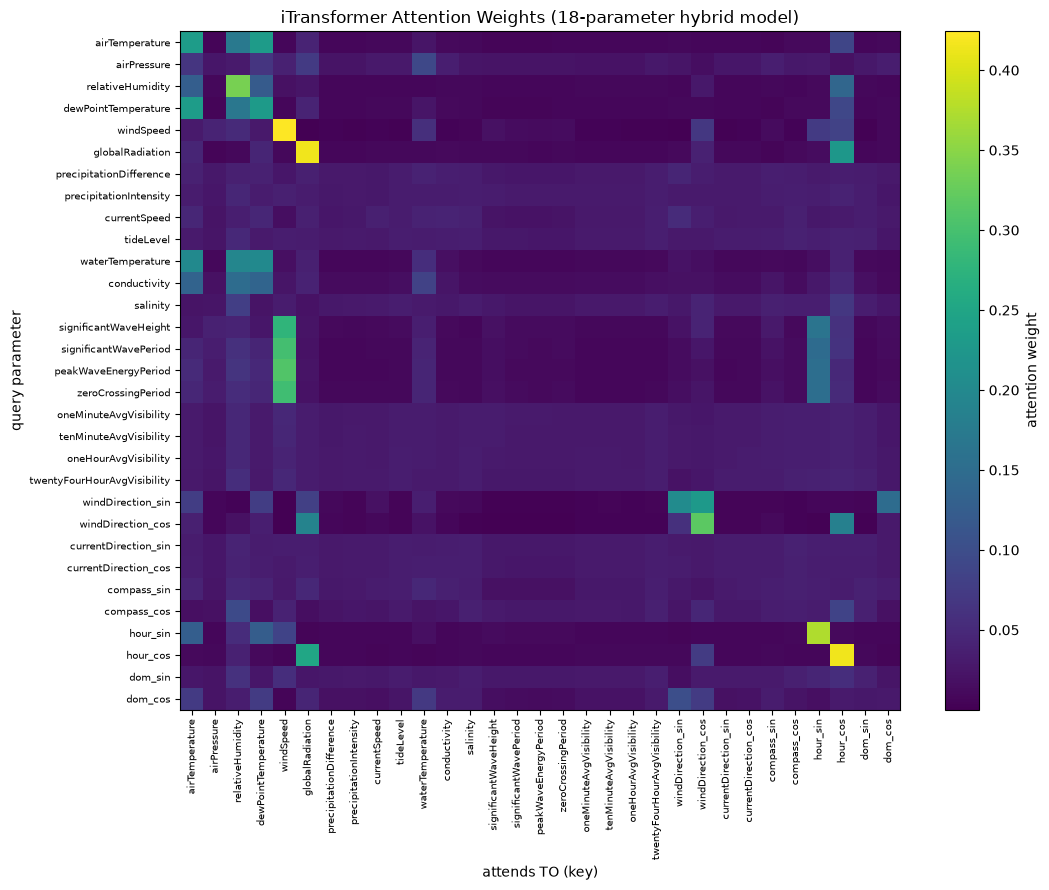

In [14]:
itransformer.eval()
with torch.no_grad():
    tok = itransformer.embed_tokens(last_window.to(device))
    layer0 = itransformer.encoder.layers[0]
    normed = layer0.norm1(tok) if layer0.norm_first else tok
    _, attn_weights = layer0.self_attn(normed, normed, normed, need_weights=True, average_attn_weights=True)
    attn_weights = attn_weights[0].cpu().numpy()

attn_df = pd.DataFrame(attn_weights, index=feature_cols, columns=feature_cols)
attn_df.to_csv("attention_weights_hybrid.csv")

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(attn_df.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(feature_cols))); ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(feature_cols))); ax.set_yticklabels(feature_cols, fontsize=7)
ax.set_xlabel("attends TO (key)"); ax.set_ylabel("query parameter")
ax.set_title("iTransformer Attention Weights (18-parameter hybrid model)", fontsize=12)
fig.colorbar(im, ax=ax, label="attention weight")
fig.tight_layout()
fig.savefig("attention_map_hybrid.png", dpi=110, bbox_inches="tight")
plt.show()


## 11. Save outputs for the dashboard

In [15]:
fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    fva[f"{p}__actual"] = truth[p].values
    fva[f"{p}__hybrid"] = hybrid_final[p].values
    fva[f"{p}__engine"] = ENGINE[p]
fva.to_csv("forecast_vs_actual_hybrid.csv", index=False)

dup_fva = pd.DataFrame({"timestamp": test_df.index})
for keep, drop in DUPLICATES:
    dup_fva[f"{drop}__actual"] = df_10min[drop].iloc[-HORIZON:].values
    dup_fva[f"{drop}__reconstructed"] = dup_series[drop]
dup_fva.to_csv("duplicate_forecast_vs_actual_hybrid.csv", index=False)

dup_recon_rows = []
for keep, drop in DUPLICATES:
    _, slope, intercept, r2 = recon_coef[drop]
    mae = mean_absolute_error(df_10min[drop].iloc[-HORIZON:].values, dup_series[drop])
    rmse = np.sqrt(mean_squared_error(df_10min[drop].iloc[-HORIZON:].values, dup_series[drop]))
    dup_recon_rows.append({"duplicate_parameter": drop, "reconstructed_from": keep,
                            "engine": ENGINE[keep], "slope": round(slope, 4),
                            "intercept": round(intercept, 4), "train_R2": round(r2, 5),
                            "held_out_MAE": round(mae, 4), "held_out_RMSE": round(rmse, 4)})
pd.DataFrame(dup_recon_rows).to_csv("duplicate_reconstruction_hybrid.csv", index=False)

print("Saved: metrics_hybrid.csv, forecast_vs_actual_hybrid.csv, duplicate_reconstruction_hybrid.csv,")
print("       duplicate_forecast_vs_actual_hybrid.csv, attention_weights_hybrid.csv, plot PNGs.")


Saved: metrics_hybrid.csv, forecast_vs_actual_hybrid.csv, duplicate_reconstruction_hybrid.csv,
       duplicate_forecast_vs_actual_hybrid.csv, attention_weights_hybrid.csv, plot PNGs.


## 12. Conclusion

This hybrid directly tests the project's recurring finding — there is no single best
model, only a best model *per parameter* — at the smallest possible scale: 2 models, 24
parameters, with the split decided by one notebook's measured failure modes. Section 8's
table is the actual verdict: if the mean improvement on the 6 hard parameters is
positive, the swap helped (even if those parameters remain hard in absolute terms — full
persistence beats every model tested on bursty precipitation, by design, since there's
nothing in 28 days of training data resembling genuine predictive signal there). If it's
roughly flat, that's still a useful negative result: it would mean these 6 parameters'
near-unforecastability is a **data** ceiling, not a **model-choice** problem — no
amount of swapping architectures fixes too few rare events in too little history.
